### Example Usage

Below is an example of forced alignment on a sample from Librispeech. We will use the slow method of alignment (Python backend) so we can also get our trellis for visualization!


In [57]:
import re
import json
import numpy as np
import librosa
import IPython.display as ipd
import ipywidgets as widgets
from IPython.display import display
from transformers import AutoModelForCTC, AutoProcessor
from ctc_forced_aligner import align, load_for_inference, \
    get_word_alignments, CTCEmissionExtractor

path_to_audio = "sample_audio/sample.wav"
transcript = "THE BEAR SHOOK HIS SHAGGY SIDES AND THEN A WELL KNOWN VOICE REPLIED"
device = "cuda"

### Set the Huggingface Backbone
ctc_model_backbone = "facebook/wav2vec2-base-960h"
model = AutoModelForCTC.from_pretrained(ctc_model_backbone).to(device)
processor = AutoProcessor.from_pretrained(ctc_model_backbone)

### Load Audio ###
inputs = load_for_inference(path_to_audio, processor)

### Extract Emissions (log probs) ###
extractor = CTCEmissionExtractor(model)
emissions, time_per_embed = extractor(inputs) # -> (num_timesteps x vocab_size)

### Prepare Text ###
def prep_text(text):
    """wav2vec2 has only uppercase and space characters"""
    return re.sub(r"[^A-Za-z ]", "", text).upper()
transcript = prep_text(transcript)

### Compute Character Alignment ###
char2id = processor.tokenizer.get_vocab()
char_alignments, trellis = align(emissions, transcript, 
                                 char2id, blank_token="|", 
                                 fast=False, return_trellis=True)
print("Sample Character Alignments")
for a in char_alignments[:10]:
    print(a)
print()

### Compute Word Alignments ###
duration = librosa.get_duration(path=path_to_audio)
word_alignments = get_word_alignments(char_alignments, transcript, 
                                      time_per_embed, duration)

print("Sample Word Alignments")
for a in word_alignments:
    print(a)


Sample Character Alignments
(0, 30)
(30, 31)
(31, 32)
(32, 35)
(35, 38)
(38, 40)
(40, 41)
(41, 42)
(42, 49)
(49, 50)

Sample Word Alignments
{'word': 'THE', 'start': 0.0, 'end': 0.642}
{'word': 'BEAR', 'start': 0.7021875, 'end': 0.8426250000000001}
{'word': 'SHOOK', 'start': 0.9830625000000001, 'end': 1.1435625}
{'word': 'HIS', 'start': 1.2238125, 'end': 1.3040625000000001}
{'word': 'SHAGGY', 'start': 1.404375, 'end': 1.725375}
{'word': 'SIDES', 'start': 1.84575, 'end': 2.247}
{'word': 'AND', 'start': 2.48775, 'end': 2.5479375}
{'word': 'THEN', 'start': 2.6081250000000002, 'end': 2.7084375}
{'word': 'A', 'start': 2.7886875, 'end': 2.80875}
{'word': 'WELL', 'start': 2.8689375, 'end': 3.0294375000000002}
{'word': 'KNOWN', 'start': 3.0896250000000003, 'end': 3.2701875}
{'word': 'VOICE', 'start': 3.3705000000000003, 'end': 3.5911875}
{'word': 'REPLIED', 'start': 3.6714375, 'end': 4.3936875}


### Lets Play Back the Word Alignments!

In [58]:
### Word Audio Playback ###
audio_data, sr = librosa.load(path_to_audio, sr=None)

def play_word(word_alignment):
    start_sample = int(word_alignment['start'] * sr)
    end_sample = int(word_alignment['end'] * sr)
    segment = audio_data[start_sample:end_sample]
    print(f"Playing: '{word_alignment['word']}'  ({word_alignment['start']:.2f}s → {word_alignment['end']:.2f}s)")
    display(ipd.Audio(segment, rate=sr, autoplay=True))

word_index = widgets.IntSlider(
    value=0, min=0, max=len(word_alignments)-1, step=1,
    description='Word #:', continuous_update=False,
    layout=widgets.Layout(width='500px')
)

word_label = widgets.Label(value=f"{word_alignments[0]['word']}")

play_btn = widgets.Button(description="▶ Play Word", button_style='primary')
prev_btn = widgets.Button(description="◀ Prev")
next_btn = widgets.Button(description="Next ▶")

output = widgets.Output()

def on_play(b):
    output.clear_output()
    with output:
        play_word(word_alignments[word_index.value])

def on_prev(b):
    if word_index.value > 0:
        word_index.value -= 1

def on_next(b):
    if word_index.value < len(word_alignments) - 1:
        word_index.value += 1

def on_index_change(change):
    word_label.value = f"{word_alignments[change['new']]['word']}"
    output.clear_output()
    with output:
        play_word(word_alignments[change['new']])

play_btn.on_click(on_play)
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)
word_index.observe(on_index_change, names='value')

display(widgets.VBox([
    widgets.HBox([prev_btn, play_btn, next_btn]),
    widgets.HBox([word_index, word_label]),
    output
]))

### Visualize the Trellis

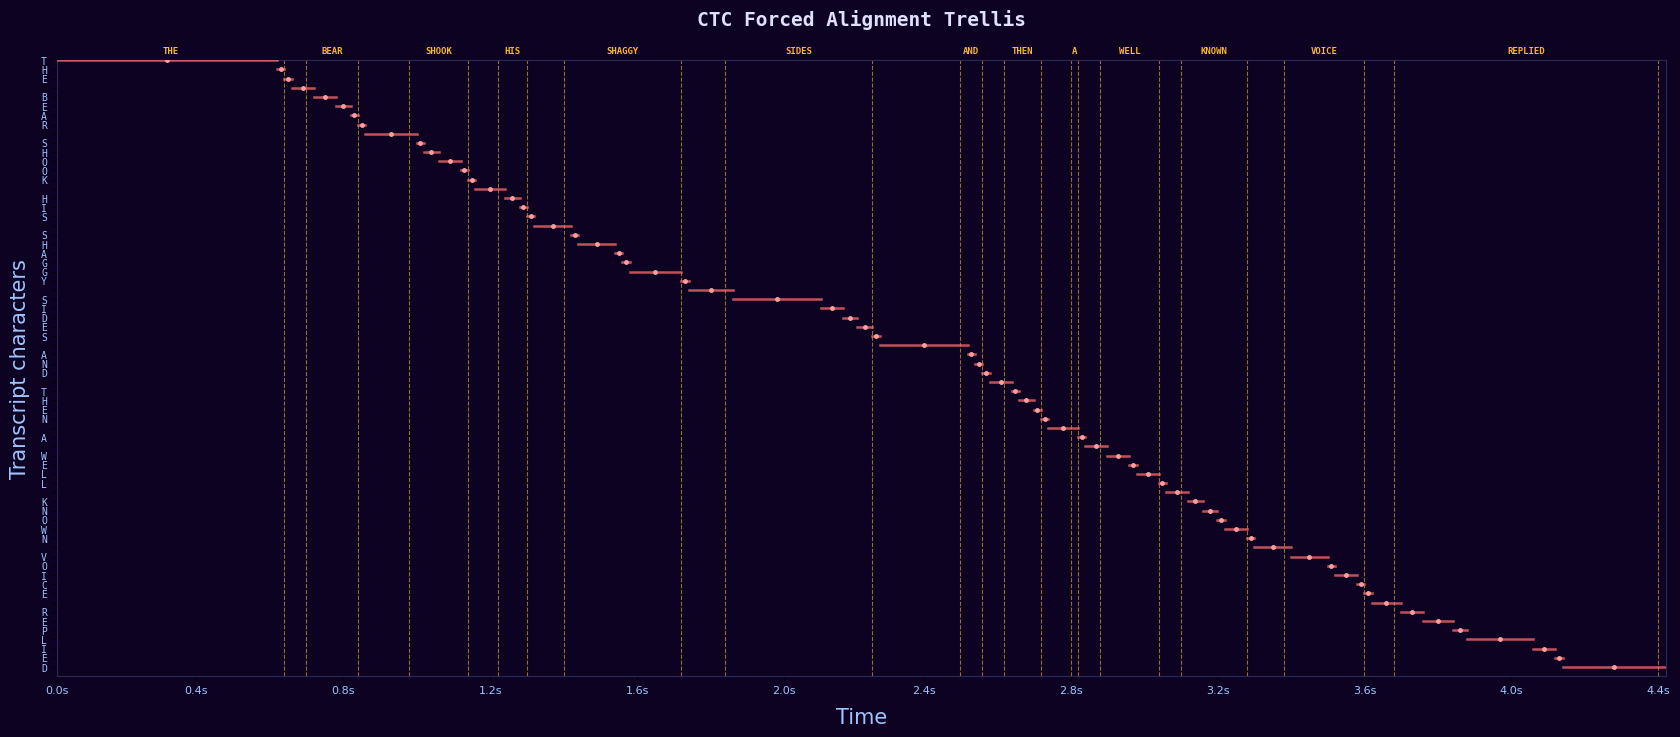

In [59]:
### Trellis Visualization ###
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

def visualize_trellis(trellis, transcript, word_alignments, char_alignments):
    chars = list(transcript)

    cmap = LinearSegmentedColormap.from_list(
        "trellis", ["#0d0221", "#1a0a3d", "#0e4d8a", "#0a9dcc", "#00f5d4"], N=512
    )

    fig = plt.figure(figsize=(min(2 + len(chars) * 0.28, 40), 8), facecolor="#0d0221")
    ax = fig.add_subplot(111)
    ax.set_facecolor("#0d0221")

    trellis_np = trellis.cpu().numpy() if hasattr(trellis, 'cpu') else np.array(trellis)
    probs_np = np.exp(trellis_np)
    num_timesteps = trellis_np.shape[0]
    duration = librosa.get_duration(path=path_to_audio)

    img = ax.imshow(
        probs_np.T,
        origin="upper",
        aspect="auto",
        cmap=cmap,
        interpolation="nearest",
        vmin=np.percentile(probs_np, 5),
        vmax=np.percentile(probs_np, 99),
        extent=[0, num_timesteps, len(chars), 0],
    )

    for i, (start, end) in enumerate(char_alignments):
        ax.plot([start, end], [i, i], color="#ff6b6b", linewidth=1.8, alpha=0.75, zorder=3)
        ax.plot([(start + end) / 2], [i], 'o', color="#ff9f9f", markersize=2.5, zorder=4)

    for wa in word_alignments:
        t_start = int(wa['start'] / duration * num_timesteps)
        t_end   = int(wa['end']   / duration * num_timesteps)
        ax.axvline(t_start, color="#f7b731", linewidth=0.8, alpha=0.6, linestyle="--", zorder=2)
        ax.axvline(t_end,   color="#f7b731", linewidth=0.8, alpha=0.6, linestyle="--", zorder=2)
        ax.text(
            (t_start + t_end) / 2, -1.5,
            wa['word'], color="#f7b731",
            fontsize=6.5, ha="center", va="top",
            fontfamily="monospace", fontweight="bold",
            clip_on=False
        )

    ax.set_yticks(range(len(chars)))
    ax.set_yticklabels(
        [repr(c)[1:-1] if c == ' ' else c for c in chars],
        fontsize=7, color="#a0c4ff", fontfamily="monospace"
    )

    n_ticks = 12
    tick_steps = np.linspace(0, num_timesteps - 1, n_ticks, dtype=int)
    tick_labels = [f"{t / num_timesteps * duration:.1f}s" for t in tick_steps]
    ax.set_xticks(tick_steps)
    ax.set_xticklabels(tick_labels, color="#a0c4ff", fontsize=8)

    ax.set_xlabel("Time", color="#a0c4ff", fontsize=15, labelpad=8)
    ax.set_ylabel("Transcript characters", color="#a0c4ff", fontsize=15, labelpad=8)
    ax.set_title("CTC Forced Alignment Trellis", color="#e0e0ff",
                 fontsize=14, fontweight="bold", pad=25, fontfamily="monospace")

    for spine in ax.spines.values():
        spine.set_edgecolor("#2a2a5a")

    path_patch = mpatches.Patch(color="#ff6b6b", label="Viterbi path")
    word_patch = mpatches.Patch(color="#f7b731", label="Word boundaries")

    plt.show()

visualize_trellis(trellis, transcript, word_alignments, char_alignments)